In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_33_PV_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_25_wind_actual.csv
/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv


In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [19]:
pv18 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv")
pv33 = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_33_PV_actual.csv")

print("PV18 Shape:", pv18.shape)
print("PV33 Shape:", pv33.shape)

PV18 Shape: (35040, 501)
PV33 Shape: (35040, 501)


In [20]:
pv18_num = pv18.drop(columns=["timestamp"])
pv33_num = pv33.drop(columns=["timestamp"])

In [21]:
pv18_num = pv18_num.apply(pd.to_numeric, errors='coerce')
pv33_num = pv33_num.apply(pd.to_numeric, errors='coerce')

In [22]:
pv18_vals = pv18_num.values.flatten()
pv33_vals = pv33_num.values.flatten()

pv18_vals = pv18_vals[~np.isnan(pv18_vals)]
pv33_vals = pv33_vals[~np.isnan(pv33_vals)]

print("Samples PV18:", len(pv18_vals))
print("Samples PV33:", len(pv33_vals))

Samples PV18: 17520000
Samples PV33: 17520000


In [23]:
print("Mean PV18:", np.mean(pv18_vals))
print("Mean PV33:", np.mean(pv33_vals))

print("Variance PV18:", np.var(pv18_vals))
print("Variance PV33:", np.var(pv33_vals))

Mean PV18: 0.05477740158091519
Mean PV33: 0.08214520350545662
Variance PV18: 0.009905132469917572
Variance PV33: 0.022272768734720477


In [24]:
t_stat, p_val_t = stats.ttest_ind(pv18_vals, pv33_vals)

print("T-statistic:", t_stat)
print("P-value:", p_val_t)

T-statistic: -638.5988020623656
P-value: 0.0


In [25]:
var18 = np.var(pv18_vals)
var33 = np.var(pv33_vals)

F = var18 / var33

df1 = len(pv18_vals) - 1
df2 = len(pv33_vals) - 1

p_val_f = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

print("F-statistic:", F)
print("P-value:", p_val_f)

F-statistic: 0.4447194054718802
P-value: 0.0


In [26]:
alpha = 0.05

print("\n===== FINAL CONCLUSION =====")

# T-test
if p_val_t < alpha:
    print("Reject H0 → Means are different")
else:
    print("Accept H0 → Means are same")

# F-test
if p_val_f < alpha:
    print("Reject H0 → Variability is different")
else:
    print("Accept H0 → Variability is same")


===== FINAL CONCLUSION =====
Reject H0 → Means are different
Reject H0 → Variability is different


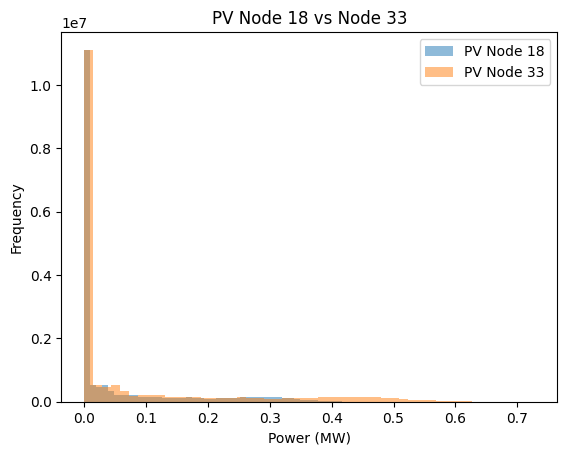

In [27]:
plt.figure()
plt.hist(pv18_vals, bins=50, alpha=0.5, label="PV Node 18")
plt.hist(pv33_vals, bins=50, alpha=0.5, label="PV Node 33")

plt.legend()
plt.title("PV Node 18 vs Node 33")
plt.xlabel("Power (MW)")
plt.ylabel("Frequency")

plt.show()